### Import packages!

In [1]:
!hostname

ne1dg6-008.nygenome.org


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime
import scanpy as sc
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from matplotlib.font_manager import FontProperties
import anndata as ad
from scipy.stats import ranksums
import matplotlib.cm as cm
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import umap
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection
import sys
import gffutils
import os

# Add the directory containing IsovizPy.py to the Python path for visualization of ATSEs and isoforms 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/visualization')
import IsovizPy as ja

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis')
# Import functions from utilities.py 
from LeafletFA_utilities import *
import importlib

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

In [3]:
# Load data and create the database (note this may take 1-2 minutes)
gtf_file = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode.v45.primary_assembly.annotation.gtf"
#db = ja.create_db(gtf_file, "gencode.v45") #do this only once! 

# Path to the database file created previously
db_path = "gencode.v45"

# Load the database
db = gffutils.FeatureDB(db_path, keep_order=True)

### Load all datasets!

In [4]:
# Specify whether GTF file was used during ATSE mapping (whether splice junctions are annotated to genes...)
gtf_used = True

# Today's date 
today = datetime.today().strftime('%Y%m%d')
# Make new directory within current working directory to store all the figures and resutls that will be generated in this notebook
results_dir = f"results_{today}"
os.makedirs(results_dir, exist_ok=True)
os.chdir(results_dir)

# Specify path that contains results from model training 
model_training_results_path = "/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/LeafletFA/analysis_20241203_135345_K_50_UsingWaypoints_Prior_GlobalPrior_NumEpochs_500_LearnedConc_Inits_1_CellType_day_Random_47072"
K = 50 # Number of learned factors 

WD="/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/LeafletFA/ATSEs"
# Note: this ATSE file was also generated through the script mentioned above
atses="iPSC_human_cells_with_annotations_50_500000_500_20241126_single_cell.gz"
ATSE_file=f"{WD}/{atses}"

In [5]:
# Splicing anndata object 
anndata = "ATSE_Anndata_noGTF_Object_20241127_151430.h5ad"
input_file = f"{WD}/{anndata}"

adata_full = ad.read_h5ad(input_file)
splice_adata = adata_full.copy()
splice_adata.obs.reset_index(drop=True, inplace=True)
splice_adata.obs["cell_id_index"] = splice_adata.obs.index 

# Load the expression data (.h5ad file)
exp_file = "/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/zenodo/gene_expression_2024-12-04.h5ad"
adata = sc.read_h5ad(exp_file)

# Mapped ATSE coordinates 
atses = pd.read_csv(ATSE_file, sep="}")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [6]:
# Load the latent variables (pickle file)
latent_vars_file = f"{model_training_results_path}/latent_vars.pkl"
latent_vars = pd.read_pickle(latent_vars_file)

# Specify prined latent variables file using 
pruned_latent_vars_file = f"{model_training_results_path}/pruned_latent_vars.pkl"
pruned_vars = pd.read_pickle(pruned_latent_vars_file)

# Load the all_vs_all results (CSV file)
albf_scores_file = f"{model_training_results_path}/all_vs_all_results.csv"
albf_scores = pd.read_csv(albf_scores_file)
albf_scores["junction_id_index"] = albf_scores["Junction_Index"]

# If GTF file was used, specify columns that include "gene_id" otherwise no "gene_id"
if gtf_used:
    juncs_factors_albf = splice_adata.var[["junction_id", "gene_id", "Cluster", "junction_id_index"]].merge(albf_scores,on="junction_id_index")
else:
    juncs_factors_albf = splice_adata.var[["junction_id", "Cluster", "junction_id_index"]].merge(albf_scores,on="junction_id_index")

### Assemble all aging related genes

In [7]:
# Aging genes from eLife paper
age_elife = "/gpfs/commons/groups/knowles_lab/Karin/elife-62293-supp3-v2.xlsx"
age_elife = pd.read_excel(age_elife, header=0, index_col=None)

# Genes for which the fraction of cells expressing significantly increases with age
supptab4 = "/gpfs/commons/groups/knowles_lab/Karin/41586_2020_2496_MOESM6_ESM.xlsx"
supptab4 = pd.read_excel(supptab4, header=0, index_col=None, sheet_name="all_genes")

# Microglia AD signature vs healthy, not sure how to interpret the 500 genes here...  
supptab10 = "/gpfs/commons/groups/knowles_lab/Karin/41586_2020_2496_MOESM12_ESM.xlsx"
supptab10 = pd.read_excel(supptab10, header=1, index_col=None, sheet_name="Amit_expression_mic3tomic1")

# Global aging genes from TMS paper
global_aging_genes = "/gpfs/commons/groups/knowles_lab/Karin/27857814" # from https://figshare.com/articles/dataset/tms_gene_data_rv1/12827615?file=27857814
global_aging_genes = pd.read_csv(global_aging_genes, sep='\t')

# TMS genes 
tms_paper = global_aging_genes["global_aging_genes"].unique()
age_elife_global = age_elife[age_elife["global_aging"]].gene.unique()

# Combine both lists into one, then use set() to remove duplicates
combined_genes = list(set(tms_paper.tolist() + age_elife_global.tolist()))

# Print the number of unique genes
print(f"Total unique genes: {len(combined_genes)}")

Total unique genes: 330


### Load list of RBPs and senescence markers!

In [8]:
# RBP file
excel_file = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

# Load the Excel file
rbps = pd.read_excel(excel_file, header=1, index_col=None)
# Rename the first two columns to be gene_name and gene_id 
rbps.rename(columns={rbps.columns[0]: 'gene_name', rbps.columns[1]: 'gene_id'}, inplace=True)

# Convert the gene_name column to capitalize only the first letter and lowercase the rest
rbps['mouse_gene_name'] = rbps['gene_name'].str.capitalize()
print(rbps[['gene_name', 'mouse_gene_name', 'gene_id']].head())

  gene_name mouse_gene_name          gene_id
0      A1CF            A1cf  ENSG00000148584
1      AARS            Aars  ENSG00000090861
2      AATF            Aatf  ENSG00000108270
3     ABCF1           Abcf1  ENSG00000204574
4      ABT1            Abt1  ENSG00000146109


### Load latent splicing factors!

In [9]:
assign_post = pruned_vars["pruned_assign_post"]
psi_learned = pruned_vars["pruned_psi_learned"]
pi = pruned_vars["pruned_pi"]

# let's get a new junc_ratio by multiplying psi_assigned and learned PSI! then use that to plot junnction usagea cross cells from different age groups.
new_junc_ratio = assign_post @ psi_learned
splice_adata.layers["new_junc_ratio"] = new_junc_ratio

psi_learned = psi_learned
psi_learned_df = pd.DataFrame(psi_learned.T, columns=[f'factor_{i}' for i in range(1, K + 1)])
psi_learned_df["junction_id_index"] = psi_learned_df.index
psi_learned_df = psi_learned_df.merge(splice_adata.var, on="junction_id_index")
splice_adata.var = psi_learned_df

### Figure out which latent spaces are associated with aging

In [10]:
# Step 1: Convert assign_post to a DataFrame and name the columns as 'factor_0', 'factor_1', ..., 'factor_49'
factor_names = [f'factor_{i}' for i in range(1, K + 1)]
assign_post_df = pd.DataFrame(assign_post, columns=factor_names)
assign_post_df.index = splice_adata.obs.index
# Step 2: Attach the factor names DataFrame (assign_post_df) to adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, assign_post_df], axis=1)

### Run logistic regression to predict age as a categorical variable! 

In [11]:
# keep only common cells between splice_adata and adata 
adata = adata[adata.obs["cell_name"].isin(splice_adata.obs["cell_name"])]
splice_adata = splice_adata[splice_adata.obs["cell_name"].isin(adata.obs["cell_name"])]

In [12]:
# Convert 'order_cells' to a plain list or pandas Index
order_cells = splice_adata.obs["cell_name"].tolist()

# Subset and reorder adata to match 'order_cells'
adata = adata[order_cells]

splice_adata.obs["pseudo"] = adata.obs["pseudo"].values
splice_adata.obs["dev_stage"] = adata.obs["dev_stage"].values

/scratch/ipykernel_1832301/3004613062.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  splice_adata.obs["pseudo"] = adata.obs["pseudo"].values
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [55]:
splice_adata.obs

,cell_id,library_name,donor,day,experiment,plate_id,plate_well_id,donor_short_id,donor_long_id,cell_id_index,...,factor_43,factor_44,factor_45,factor_46,factor_47,factor_48,factor_49,factor_50,pseudo,dev_stage
cell_name,,,,,,,,,,,,,,,,,,,,,
21241_6#191,ERR1737741,NT852065S,fafq,day3,expt_10,246.0,0246_H23,fafq_1,HPSI0314i-fafq_1,42,...,0.004514,0.002885,0.002732,0.002275,0.005554,0.000347,0.000926,0.001766,0.730099,defendo
21241_6#192,ERR1737742,NT852066T,garx,day3,expt_10,246.0,0246_H24,garx_2,HPSI1013i-garx_2,43,...,0.001951,0.003592,0.007838,0.001648,0.000318,0.000972,0.001528,0.002527,0.820004,defendo
21241_6#261,ERR1737811,NT852135P,sojd,day3,expt_10,246.0,0246_K21,sojd_3,HPSI0314i-sojd_3,45,...,0.003228,0.001649,0.005404,0.002102,0.006271,0.000665,0.003110,0.000751,0.746475,defendo
21241_6#353,ERR1737903,NT852227S,sebz,day3,expt_10,246.0,0246_O17,sebz_1,HPSI1013i-sebz_1,46,...,0.001722,0.002538,0.012959,0.009553,0.005890,0.002345,0.000671,0.000765,0.750053,defendo
21241_7#9,ERR1737943,NT852268E,hayt,day1,expt_10,247.0,0247_A09,hayt_1,HPSI1113i-hayt_1,48,...,0.010463,0.002991,0.000633,0.000371,0.004074,0.006317,0.003366,0.002518,0.336336,mesendo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24327_5#278,ERR4361569,NT1200673M,suop,day1,expt_30,2039.0,2039_L14,suop_5,HPSI0914i-suop_5,43102,...,0.001624,0.002465,0.002076,0.004947,0.000898,0.001257,0.000813,0.000446,0.260511,mesendo
24327_5#301,ERR4361592,NT1200696T,sehl,day1,expt_30,2039.0,2039_M13,sehl_6,HPSI1014i-sehl_6,43103,...,0.004421,0.004449,0.006753,0.001010,0.006918,0.001283,0.000698,0.002520,0.243070,mesendo
24327_6#63,ERR4361738,NT1211045W,poih,day0,expt_28,1787.0,1787_C15,poih_4,HPSI0214i-poih_4,43104,...,0.032485,0.008262,0.010971,0.004765,0.002885,0.011078,0.001847,0.001280,0.138769,iPSC


In [57]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "experiment"
accuracy, coefficients_day = logistic_regression_feature_prediction_simple(splice_adata, feature, K)

# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")

# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_day = coefficients_day.apply(lambda x: x.abs().nlargest(10).index.tolist(), axis=1)
print(top_factors_by_day)

Experiment Prediction Accuracy: 0.5761
Accuracy for experiment: 0.5760823875577974
expt_10    [factor_34, factor_9, factor_8, factor_15, fac...
expt_20    [factor_5, factor_7, factor_11, factor_8, fact...
expt_23    [factor_13, factor_1, factor_7, factor_30, fac...
expt_24    [factor_20, factor_9, factor_43, factor_24, fa...
expt_27    [factor_5, factor_17, factor_12, factor_43, fa...
expt_28    [factor_13, factor_5, factor_25, factor_15, fa...
expt_29    [factor_15, factor_4, factor_1, factor_42, fac...
expt_30    [factor_4, factor_8, factor_9, factor_38, fact...
expt_31    [factor_8, factor_1, factor_34, factor_30, fac...
expt_32    [factor_30, factor_25, factor_16, factor_3, fa...
expt_33    [factor_38, factor_13, factor_25, factor_20, f...
expt_36    [factor_2, factor_28, factor_12, factor_16, fa...
expt_37    [factor_27, factor_16, factor_36, factor_18, f...
expt_38    [factor_32, factor_8, factor_41, factor_9, fac...
expt_39    [factor_8, factor_29, factor_44, factor_16, fa...
ex

In [56]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "donor_short_id"
accuracy, coefficients_day = logistic_regression_feature_prediction_simple(splice_adata, feature, K)

# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")

# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_day = coefficients_day.apply(lambda x: x.abs().nlargest(10).index.tolist(), axis=1)
print(top_factors_by_day)

Donor_short_id Prediction Accuracy: 0.2430
Accuracy for donor_short_id: 0.24295922656578395
aowh_2    [factor_15, factor_1, factor_20, factor_11, fa...
aoxv_3    [factor_1, factor_7, factor_13, factor_33, fac...
babz_3    [factor_20, factor_43, factor_9, factor_1, fac...
bezi_1    [factor_13, factor_8, factor_1, factor_16, fac...
bima_1    [factor_18, factor_31, factor_16, factor_38, f...
                                ...                        
yelp_3    [factor_1, factor_7, factor_13, factor_47, fac...
yemz_1    [factor_9, factor_34, factor_8, factor_7, fact...
yoch_6    [factor_33, factor_34, factor_48, factor_1, fa...
zerv_8    [factor_27, factor_36, factor_9, factor_8, fac...
zihe_1    [factor_18, factor_38, factor_16, factor_7, fa...
Length: 104, dtype: object


Day Prediction Accuracy: 0.9504
Accuracy for day: 0.9503993274485077
day0    [factor_7, factor_13, factor_36, factor_9, fac...
day1    [factor_16, factor_9, factor_1, factor_26, fac...
day2    [factor_30, factor_19, factor_23, factor_16, f...
day3    [factor_1, factor_9, factor_41, factor_31, fac...
dtype: object
Figure saved as factor_age_coefficients_2024-12-05.pdf


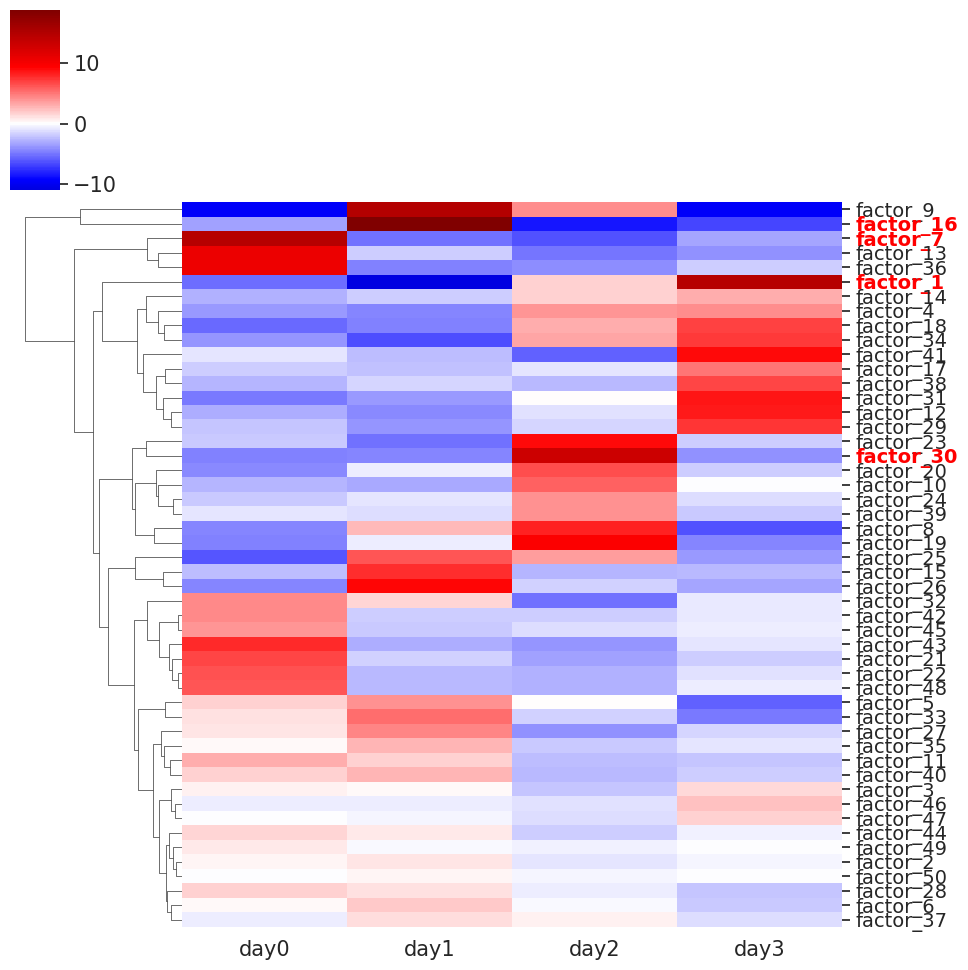

In [13]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "day"
accuracy, coefficients_day = logistic_regression_feature_prediction_simple(splice_adata, feature, K)

# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")

# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_day = coefficients_day.apply(lambda x: x.abs().nlargest(10).index.tolist(), axis=1)
print(top_factors_by_day)

plot_clustermap(coefficients_day, highlighted_factors=['factor_7', 'factor_16', 'factor_30', 'factor_1'], figsize=(10, 10))

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = data_melted.groupby(['Factor', age_column])['Contribution'].median().reset_index()


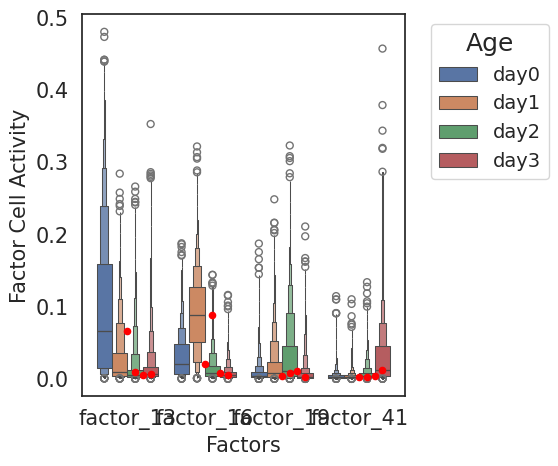

Plot saved as factor_distributions_factor_13_factor_16_factor_19_factor_41_2024-12-05.pdf


In [14]:
plot_top_factor_distributions(splice_adata, top_factors=['factor_13', 'factor_16', 'factor_19', 'factor_41'], age_column="day", plot_type="boxenplot")

Dev_stage Prediction Accuracy: 0.8159
                 factor_1  factor_2  factor_3  factor_4  factor_5  factor_6  \
defendo         10.679929 -1.678813 -0.079018  5.564802 -0.032197 -2.221305   
iPSC            -4.441517  0.448821 -1.208062 -5.928877 -3.813933 -1.213345   
int_unassigned   5.390533  0.144924  0.661563  2.448448 -0.562084  0.849213   
mesendo        -11.628945  1.085068  0.625517 -2.084373  4.408214  2.585437   

                 factor_7  factor_8  factor_9  factor_10  ...  factor_41  \
defendo         -5.506991 -1.596110 -2.095536   5.613095  ...   2.824624   
iPSC            12.796289 -2.095397 -8.401317  -2.366140  ...  -1.749405   
int_unassigned  -7.044990  3.071483  2.293819   1.566191  ...   0.784932   
mesendo         -0.244307  0.620024  8.203033  -4.813146  ...  -1.860152   

                factor_42  factor_43  factor_44  factor_45  factor_46  \
defendo         -1.565219  -2.301583  -0.784939  -0.669694   1.914043   
iPSC             8.603089   2.650950   

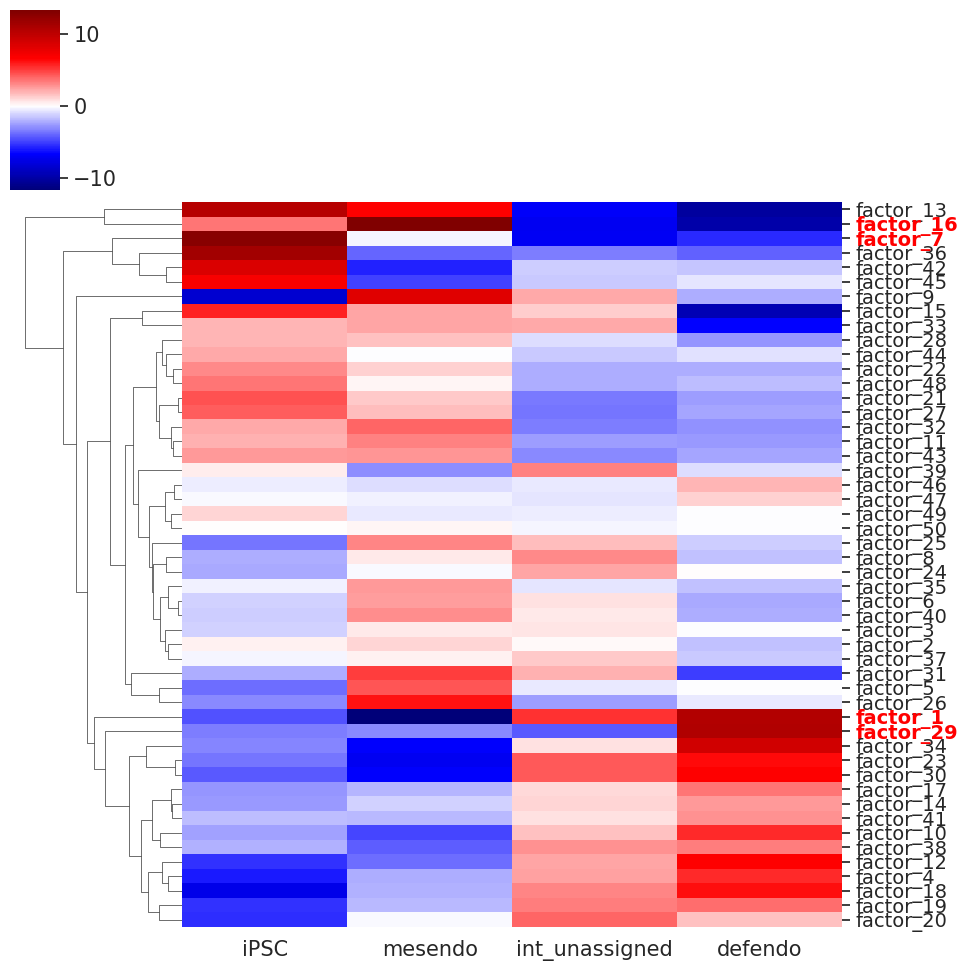

In [15]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "dev_stage"
accuracy, coefficients_dev = logistic_regression_feature_prediction_simple(splice_adata, feature, K)
print(coefficients_dev)

# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")

# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_dev = coefficients_dev.apply(lambda x: x.abs().nlargest(10).index.tolist(), axis=1)
print(top_factors_by_dev)

# reorder coefficients_dev to match the order of dev_stage
coefficients_dev = coefficients_dev.reindex(["iPSC", "mesendo", "int_unassigned", "defendo"])

plot_clustermap(coefficients_dev, highlighted_factors=['factor_29', 'factor_7', 'factor_16', 'factor_1'], figsize=(10, 10))

### Get UMAP based on assign_post embeddings in splice_data.obs columns with "factor" in them 

In [16]:
# Step 1: Extract the assign_post embeddings from splice_data.obs
# Get all columns with 'factor' in their names
factor_columns = [col for col in splice_adata.obs.columns if 'factor' in col]
embedding = splice_adata.obs[factor_columns].values

# Step 2: Perform UMAP on the factor embeddings
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = reducer.fit_transform(embedding)
splice_adata.obsm['X_umap'] = umap_embedding

shuffled_indices = np.random.permutation(splice_adata.obs.index)
shuffled_adata = splice_adata[shuffled_indices, :]

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [19]:
# get gene_id and gene_name from atses to merge onto splice_adata.var
splice_adata.var = splice_adata.var.merge(atses[["junction_id", "gene_name"]], on="junction_id")

In [20]:
if gtf_used:
    genes_ids = atses[["gene_id", "gene_name"]].drop_duplicates()
    aging_genes = global_aging_genes[global_aging_genes["global_aging_genes"].isin(splice_adata.var["gene_name"])].global_aging_genes.values
    genes_ids['aging_genes'] = genes_ids['gene_name'].isin(combined_genes).map({True: 'yes', False: 'no'})
    genes_ids.aging_genes.value_counts()
    juncs_factors_albf = juncs_factors_albf.merge(genes_ids)

### Look at ALBF scores of junction within a specific factor

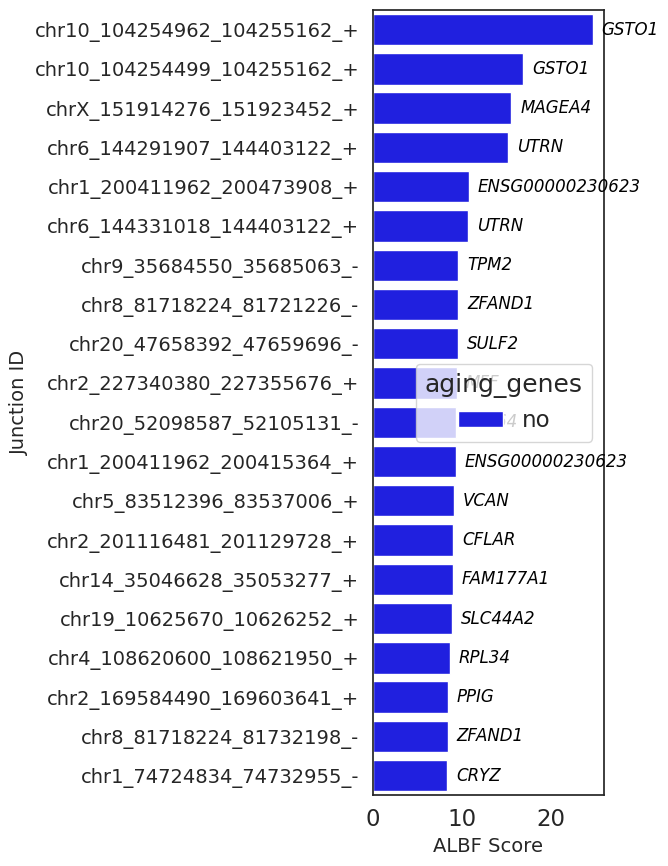

In [23]:
# Step 1: Select factor of interest 
factor_int = "Factor 16" 

if gtf_used:

    subset_df = juncs_factors_albf[juncs_factors_albf["Factor"] == factor_int]
    
    # Step 2: Sort first by 'aging_genes' (placing 'yes' first) and then by 'ALBF' in descending order
    sorted_df = subset_df.sort_values(by=["aging_genes", "ALBF"], ascending=[False, False])
    sorted_df = subset_df.sort_values(by="ALBF", ascending=False)
    
    # Step 2: Select the top 50 junctions
    top_50_junctions = sorted_df.head(20)
    
    # Step 3: Create a bar plot to show the top 50 junctions and their ALBF scores
    plt.figure(figsize=(7, 9))
    
    # Define colors based on the aging_genes column ('yes' for aging genes, 'no' for non-aging genes)
    color_palette = {'yes': 'red', 'no': 'blue'}
    
    # Plot the barplot with different colors based on the aging_genes column
    sns.barplot(x="ALBF", y="junction_id", data=top_50_junctions, hue="aging_genes", dodge=False, palette=color_palette)
    
    # Italicize gene names
    italic_font = FontProperties(style='italic')
    
    # Add the gene names as labels for each junction with italic font
    for i in range(top_50_junctions.shape[0]):
        plt.text(top_50_junctions["ALBF"].values[i] + 1, i, 
                 top_50_junctions["gene_name"].values[i], 
                 fontproperties=italic_font, color='black', va="center", fontsize=12)
    
    # Set labels and title
    plt.xlabel("ALBF Score", fontsize=14)
    plt.ylabel("Junction ID", fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{factor_int}_top_junctions.pdf", format='pdf')
    
    # Show the plot
    plt.show()

### Gets PCs and UMAP on gene expression anndata object

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:664: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm["X_pca"] = X_pca


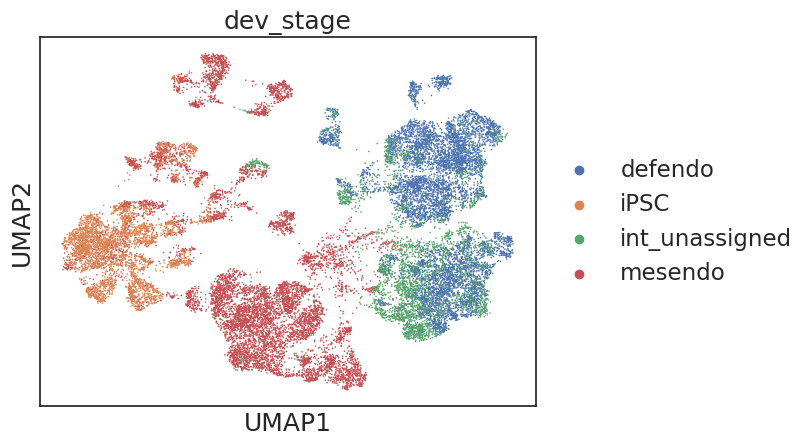

In [27]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)

# Subset to highly variable genes 
adata = adata[:, adata.var['highly_variable']]

# PCA computation
sc.tl.pca(adata, n_comps=50)  

# Compute UMAP
sc.pp.neighbors(adata, n_pcs=30, use_rep='X_pca')  # Construct neighborhood graph
sc.tl.umap(adata)  # Compute UMAP embedding

# Plot UMAP
sc.pl.umap(adata, color=['dev_stage']) 

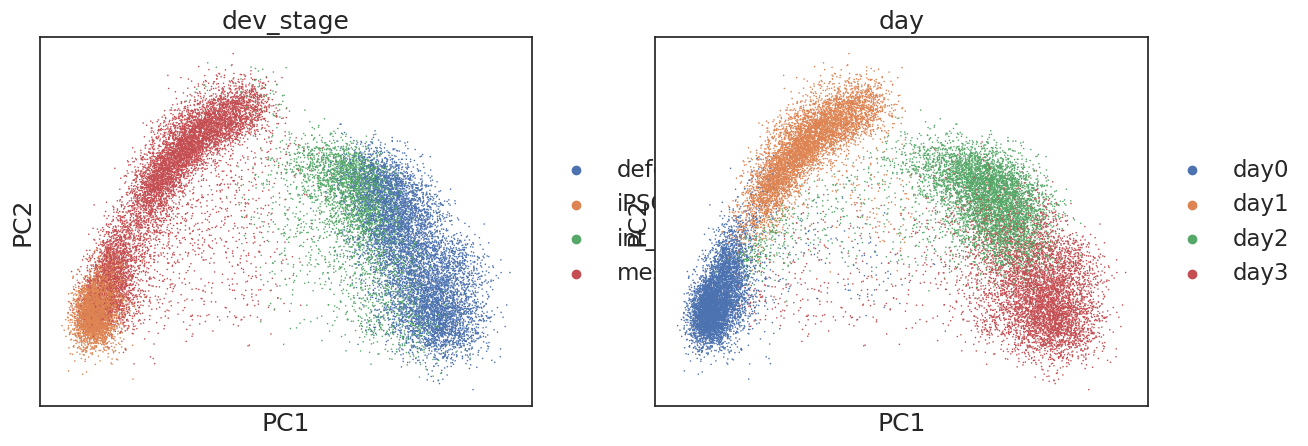

In [29]:
# plot gene expression PCA 
sc.pl.pca(adata, color=['dev_stage', 'day'])

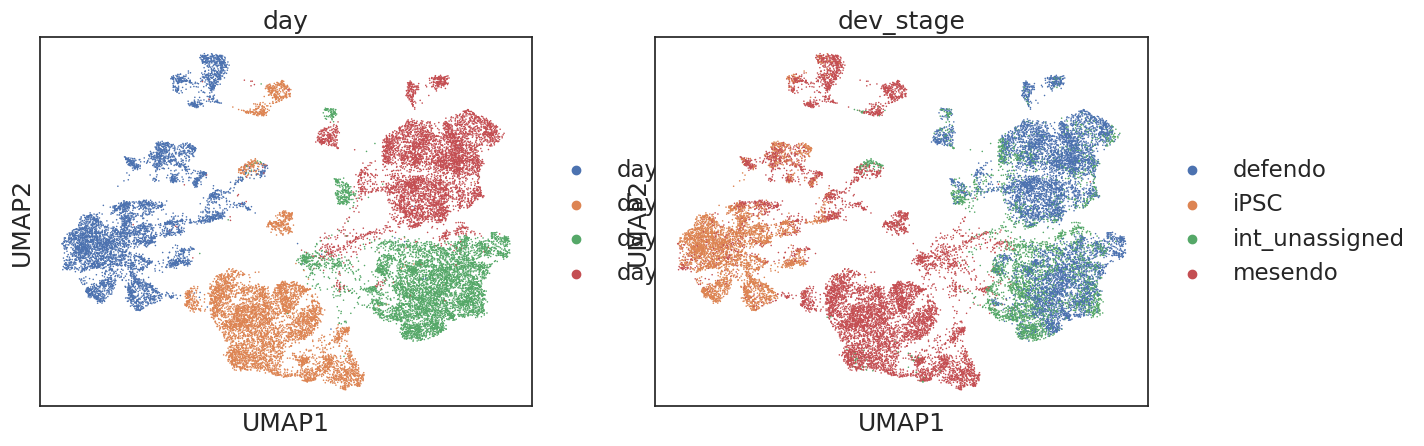

In [32]:
sc.pl.umap(adata, color=['day', 'dev_stage']) 

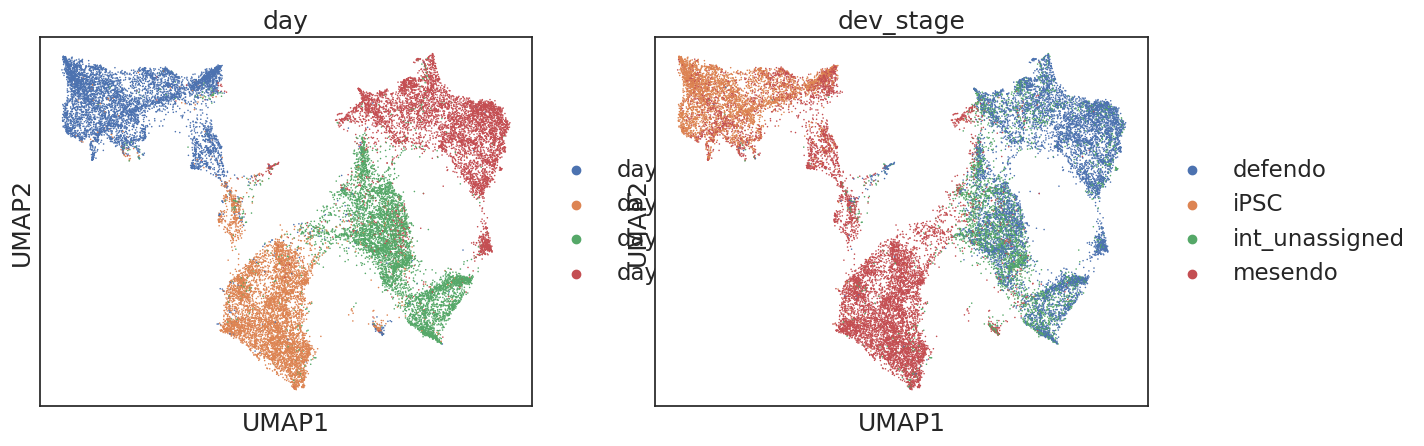

In [33]:
# plot splicing UMAP 
sc.pl.umap(splice_adata, color=['day', 'dev_stage']) 

### Rerun logistic regression to predict age groups comparing splicing vs gene expression based signals

In [105]:
def logistic_regression_feature_prediction(
    splice_adata,
    gene_expression_adata,
    feature: str,
    K: int = 50,
    n_pcs: int = 50,
    covariate_column: str = None,  # Allow any covariate column
    test_size: float = 0.2,
    random_state: int = 42
):
    """
    Train and evaluate multinomial logistic regression models using splicing factors,
    gene expression PCs, a covariate column, and their combination to predict the feature of interest.
    
    Parameters:
    - splice_adata: AnnData object containing splicing data with latent factors in `obs`.
    - gene_expression_adata: AnnData object containing gene expression data.
    - feature: str, name of the feature to predict (e.g., 'age', 'cell_type_grouped').
    - K: int, number of splicing latent factors to use.
    - n_pcs: int, number of gene expression PCs to use.
    - covariate_column: str, name of the covariate column in `splice_adata.obs`.
    - test_size: float, proportion of the data to use for testing.
    - random_state: int, seed for reproducibility.
    
    Returns:
    - accuracies: dict, accuracy scores for each model.
    - aurocs: dict, AUROC scores for each model.
    - auprs: dict, AUPR scores for each model.
    - models: dict, trained LogisticRegression models.
    - label_encoder: LabelEncoder instance used to encode the target variable.
    - coefficients_dfs: dict, DataFrames with logistic regression coefficients for each model.
    """

    # Step 1: Extract splicing latent factors
    latent_factors = [f'factor_{i}' for i in range(1, K + 1)]
    X_splicing = splice_adata.obs[latent_factors]
    
    # Step 2: Compute gene expression PCs
    pcs = gene_expression_adata.obsm['X_pca'][:, :n_pcs]
    pc_columns = [f'PC_{i+1}' for i in range(n_pcs)]
    X_gene_expression = pd.DataFrame(pcs, index=gene_expression_adata.obs_names, columns=pc_columns)
    
    # Step 3: Handle covariate column
    if covariate_column:
        covariate_encoder = OneHotEncoder()
        covariate_data = covariate_encoder.fit_transform(splice_adata.obs[[covariate_column]])
        covariate_columns = [
            f'{covariate_column}_{cat}' for cat in covariate_encoder.categories_[0]
        ]
        X_covariate = pd.DataFrame(
            covariate_data.toarray(), index=splice_adata.obs_names, columns=covariate_columns
        )
        # Add covariate to splicing and gene expression datasets
        X_splicing = pd.concat([X_splicing, X_covariate], axis=1)
        X_gene_expression = pd.concat([X_gene_expression, X_covariate], axis=1)
        # Scale the X_splicing and X_gene_expression after adding the covariate
        scaler = StandardScaler()
        X_splicing = pd.DataFrame(scaler.fit_transform(X_splicing), index=X_splicing.index, columns=X_splicing.columns)
        X_gene_expression = pd.DataFrame(scaler.fit_transform(X_gene_expression), index=X_gene_expression.index, columns=X_gene_expression.columns)
    
    else:
        print("No covariate column provided. Please provide a valid covariate column.")
        

    # Step 4: Prepare combined dataset and scale it
    X_combined = pd.concat([X_splicing, X_gene_expression], axis=1)
    scaler = StandardScaler()
    X_combined_scaled = pd.DataFrame(scaler.fit_transform(X_combined), index=X_combined.index, columns=X_combined.columns)

    # Step 5: Encode the target variable
    label_encoder = LabelEncoder()
    y = splice_adata.obs[feature].astype(str)  # Ensure the feature is a string type
    y_encoded = label_encoder.fit_transform(y)
    
    # Step 6: Split the data
    X_train_s, X_test_s, y_train, y_test = train_test_split(
        X_splicing, y_encoded, test_size=test_size, random_state=random_state
    )
    X_train_g, X_test_g, _, _ = train_test_split(
        X_gene_expression, y_encoded, test_size=test_size, random_state=random_state
    )
    X_train_c, X_test_c, _, _ = train_test_split(
        X_combined_scaled, y_encoded, test_size=test_size, random_state=random_state
    )
    X_train_cov, X_test_cov, _, _ = train_test_split(
        X_covariate, y_encoded, test_size=test_size, random_state=random_state
    )

    # Step 7: Train logistic regression models
    logreg_params = {
        'multi_class': 'multinomial',
        'solver': 'lbfgs',
        'max_iter': 1000,
        'random_state': random_state
    }

    model_splicing = LogisticRegression(**logreg_params)
    model_gene_expression = LogisticRegression(**logreg_params)
    model_combined = LogisticRegression(**logreg_params)
    model_cov = LogisticRegression(**logreg_params)
    
    model_splicing.fit(X_train_s, y_train)
    model_gene_expression.fit(X_train_g, y_train)
    model_combined.fit(X_train_c, y_train)
    model_cov.fit(X_train_cov, y_train)
    
    # Step 8: Evaluate the models
    y_pred_s = model_splicing.predict(X_test_s)
    y_pred_g = model_gene_expression.predict(X_test_g)
    y_pred_c = model_combined.predict(X_test_c)
    y_pred_cov = model_cov.predict(X_test_cov)

    accuracy_s = accuracy_score(y_test, y_pred_s)
    accuracy_g = accuracy_score(y_test, y_pred_g)
    accuracy_c = accuracy_score(y_test, y_pred_c)
    accuracy_cov = accuracy_score(y_test, y_pred_cov)
    
    y_prob_s = model_splicing.predict_proba(X_test_s)
    y_prob_g = model_gene_expression.predict_proba(X_test_g)
    y_prob_c = model_combined.predict_proba(X_test_c)
    y_prob_cov = model_cov.predict_proba(X_test_cov)

    try:
        auroc_s = roc_auc_score(y_test, y_prob_s, multi_class='ovr')
        auroc_g = roc_auc_score(y_test, y_prob_g, multi_class='ovr')
        auroc_c = roc_auc_score(y_test, y_prob_c, multi_class='ovr')
        auroc_cov = roc_auc_score(y_test, y_prob_cov, multi_class='ovr')
        
        aupr_s = average_precision_score(y_test, y_prob_s, average='macro')
        aupr_g = average_precision_score(y_test, y_prob_g, average='macro')
        aupr_c = average_precision_score(y_test, y_prob_c, average='macro')
        aupr_cov = average_precision_score(y_test, y_prob_cov, average='macro')
    except ValueError as e:
        print(f"Error calculating AUROC/AUPR: {e}")
        auroc_s = auroc_g = auroc_c = None
        aupr_s = aupr_g = aupr_c = None

    # Print results
    print(f"Splicing Accuracy: {accuracy_s:.4f}, AUROC: {auroc_s}, AUPR: {aupr_s}")
    print(f"Gene Expression Accuracy: {accuracy_g:.4f}, AUROC: {auroc_g}, AUPR: {aupr_g}")
    print(f"Combined Features Accuracy: {accuracy_c:.4f}, AUROC: {auroc_c}, AUPR: {aupr_c}")
    print(f"Covariate Accuracy: {accuracy_cov:.4f}, AUROC: {auroc_cov}, AUPR: {aupr_cov}")

    # Retrain models for coefficients
    model_splicing.fit(X_splicing, y_encoded)
    model_gene_expression.fit(X_gene_expression, y_encoded)
    model_combined.fit(X_combined_scaled, y_encoded)
    model_cov.fit(X_covariate, y_encoded)
    
    coef_splicing = pd.DataFrame(
        model_splicing.coef_, columns=list(X_splicing.columns), index=label_encoder.classes_
    )
    coef_gene_expression = pd.DataFrame(
        model_gene_expression.coef_, columns=list(X_gene_expression.columns), index=label_encoder.classes_
    )
    coef_combined = pd.DataFrame(
        model_combined.coef_, columns=list(X_combined.columns), index=label_encoder.classes_
    )
    coef_cov = pd.DataFrame(
        model_cov.coef_, columns=list(X_covariate.columns), index=label_encoder.classes_
    )
    
    # Collect results
    accuracies = {
        'splicing': accuracy_s,
        'gene_expression': accuracy_g,
        'combined': accuracy_c,
        'covariate': accuracy_cov
    }
    
    aurocs = {
        'splicing': auroc_s,
        'gene_expression': auroc_g,
        'combined': auroc_c,
        'covariate': auroc_cov
    }
    
    auprs = {
        'splicing': aupr_s,
        'gene_expression': aupr_g,
        'combined': aupr_c,
        'covariate': aupr_cov
    }
    
    models = {
        'splicing': model_splicing,
        'gene_expression': model_gene_expression,
        'combined': model_combined,
        'covariate': model_cov
    }
    
    coefficients_dfs = {
        'splicing': coef_splicing,
        'gene_expression': coef_gene_expression,
        'combined': coef_combined,
        'covariate': coef_cov
    }
    
    return accuracies, aurocs, auprs, models, label_encoder, coefficients_dfs


In [106]:
splice_adata.obs.set_index("cell_name", inplace=True)

KeyError: "None of ['cell_name'] are in the columns"

In [107]:
# get linear regression estimate of how well factors predict pseudo column 
feature = "pseudo"
latent_factors = [f'factor_{i}' for i in range(1, K + 1)]
X = splice_adata.obs[latent_factors]
y = splice_adata.obs[feature]
X = sm.add_constant(X)

# Split the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train multivariate linear regression model
model = sm.OLS(y_train, X_train).fit()

# Evaluate the model on test set 
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

# get coefficients from the full model trained aon full dataset
linreg_full = sm.OLS(y, X).fit()
# Get the linear regression coefficients, confidence intervals, and p-values
coefficients = linreg_full.params
conf_intervals = linreg_full.conf_int()
std_errors = linreg_full.bse

# Create a DataFrame with coefficients and confidence intervals
coefficients_df = pd.DataFrame({
        'Factor': ['Intercept'] + latent_factors,
        'Coefficient': coefficients,
        'Lower CI': conf_intervals[0],
        'Upper CI': conf_intervals[1],
        'Standard Error': std_errors
    })

Mean Squared Error: 0.004883778807076684
Root Mean Squared Error: 0.06988403828541025


In [108]:
# sort by absolute coefficient value
coefficients_df = coefficients_df.reindex(coefficients_df['Coefficient'].abs().sort_values(ascending=False).index)
coefficients_df.head()

,Factor,Coefficient,Lower CI,Upper CI,Standard Error
factor_36,factor_36,-0.987065,-1.025471,-0.948660,0.019594
factor_42,factor_42,-0.940466,-1.024132,-0.856800,0.042685
factor_13,factor_13,-0.891994,-0.909198,-0.874790,0.008777
factor_34,factor_34,0.877350,0.853123,0.901577,0.012360
factor_29,factor_29,0.863624,0.836985,0.890262,0.013591


Text(0, 0.5, 'Pseudo')

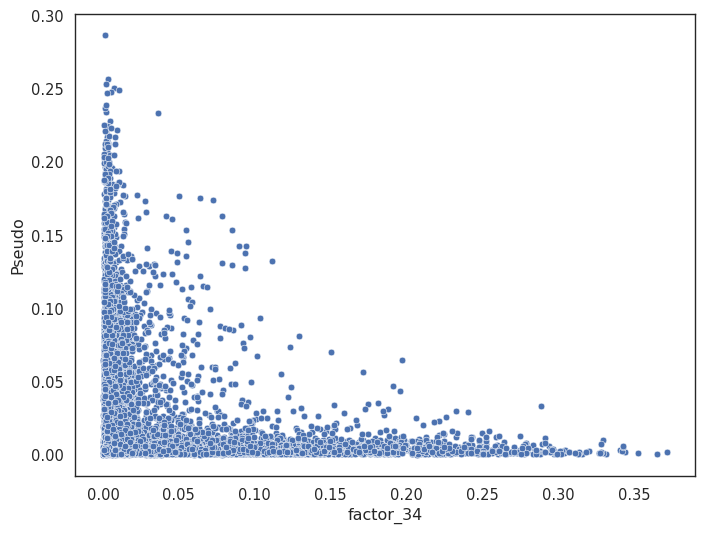

In [109]:
# plot correlation between Factor_36 cell activity and pseudo column
plt.figure(figsize=(8, 6))
sns.scatterplot(x="factor_34", y="factor_36", data=splice_adata.obs)
plt.xlabel("factor_34")
plt.ylabel("Pseudo")

In [110]:
# Assume splice_adata and gene_expression_adata are already loaded and preprocessed
feature_to_predict = 'dev_stage' 

accuracies, aurocs, auprs, models, label_encoder, coefficients_dfs = logistic_regression_feature_prediction(
    splice_adata,
    adata,
    feature=feature_to_predict,
    covariate_column = "experiment",
    K=K,
    n_pcs=50,
    test_size=0.3,
    random_state=4100
)

print(accuracies)

Splicing Accuracy: 0.8497, AUROC: 0.9698747612711082, AUPR: 0.8858772898135923
Gene Expression Accuracy: 0.9334, AUROC: 0.9944446486863545, AUPR: 0.9783860351949096
Combined Features Accuracy: 0.9372, AUROC: 0.9948367940522858, AUPR: 0.9798139207211349
Covariate Accuracy: 0.4676, AUROC: 0.6786103337639667, AUPR: 0.383570262846994
{'splicing': 0.8496567185091776, 'gene_expression': 0.9334454252487039, 'combined': 0.9372285273924618, 'covariate': 0.4675634019896315}


In [111]:
coefficients_dfs.keys()

dict_keys(['splicing', 'gene_expression', 'combined', 'covariate'])

In [112]:
coef_splicing = coefficients_dfs['splicing']
coef_gene_expression = coefficients_dfs['gene_expression']
coef_combined = coefficients_dfs['combined']
coef_cov_only = coefficients_dfs['covariate']

In [113]:
# Assume splice_adata and gene_expression_adata are already loaded and preprocessed
feature_to_predict = 'day' 

accuracies, aurocs, auprs, models, label_encoder, coefficients_days = logistic_regression_feature_prediction(
    splice_adata,
    adata,
    feature=feature_to_predict,
    covariate_column = "experiment",
    K=K,
    n_pcs=50,
    test_size=0.3,
    random_state=4100
)

print(accuracies)

Splicing Accuracy: 0.9844, AUROC: 0.9993913665297516, AUPR: 0.9982960743704256
Gene Expression Accuracy: 0.9983, AUROC: 0.9999808305133555, AUPR: 0.9999430106340543
Combined Features Accuracy: 0.9975, AUROC: 0.9999685556283618, AUPR: 0.9999113228983124
Covariate Accuracy: 0.3485, AUROC: 0.6690153745651923, AUPR: 0.38273852848292017
{'splicing': 0.9844472467423288, 'gene_expression': 0.9983186212694409, 'combined': 0.9974779319041615, 'covariate': 0.3484657419083649}


In [114]:
coef_splicing

,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,...,experiment_expt_33,experiment_expt_36,experiment_expt_37,experiment_expt_38,experiment_expt_39,experiment_expt_41,experiment_expt_42,experiment_expt_43,experiment_expt_44,experiment_expt_45
defendo,1.219767,-0.024716,0.134227,0.633534,0.188038,-0.092261,-1.085894,-0.053127,-0.078308,0.421525,...,0.137906,-0.319811,-0.508605,0.083032,-0.146991,0.173379,0.111852,0.214207,-0.130574,0.078539
iPSC,-0.832075,0.002343,-0.186236,-0.679584,-0.380241,0.012847,1.687964,0.064586,-0.580474,-0.384133,...,-0.256313,0.581018,0.475868,-0.005570,-0.075432,-0.151312,-0.374875,0.003446,0.096402,0.161764
int_unassigned,0.825433,-0.015851,0.082332,0.314313,-0.010995,-0.007512,-0.956665,0.118462,0.283648,0.265839,...,0.118159,-0.071404,-0.520182,-0.079407,0.075764,-0.017815,0.212949,-0.172527,0.078269,-0.106333
mesendo,-1.213125,0.038224,-0.030322,-0.268263,0.203198,0.086926,0.354596,-0.129921,0.375134,-0.303231,...,0.000249,-0.189803,0.552919,0.001945,0.146659,-0.004253,0.050075,-0.045127,-0.044097,-0.133970


In [115]:
coef_gene_expression

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,experiment_expt_33,experiment_expt_36,experiment_expt_37,experiment_expt_38,experiment_expt_39,experiment_expt_41,experiment_expt_42,experiment_expt_43,experiment_expt_44,experiment_expt_45
defendo,18.650980,0.785863,2.539674,0.241236,-0.387501,0.307889,0.754777,-2.273829,0.484894,0.357533,...,0.163519,0.024510,1.170400,-0.071308,0.072348,0.036496,-0.005646,-0.045055,-0.167224,-0.191109
iPSC,-14.497600,-2.287390,-2.329977,-0.330867,-0.146796,-0.353979,-1.308057,2.316321,-0.499041,-0.712006,...,-0.312871,-0.081691,0.006712,-0.012191,-0.165196,-0.097835,-0.157103,0.103422,0.147114,0.284657
int_unassigned,2.526078,0.506154,0.606155,0.039520,-0.299186,0.109768,0.201530,-0.748222,-0.160396,0.492920,...,0.154456,0.113400,-1.340885,0.166415,0.096091,0.086149,0.109713,-0.016073,0.018937,-0.002167
mesendo,-6.679458,0.995373,-0.815853,0.050110,0.833484,-0.063677,0.351750,0.705731,0.174543,-0.138448,...,-0.005104,-0.056219,0.163773,-0.082916,-0.003243,-0.024810,0.053035,-0.042294,0.001174,-0.091381


### Calcualte Entropy and Perplexity across Cells

In [64]:
# subset assign_post to just the cell_index still present in splice_adata.obs 
assign_post = assign_post[splice_adata.obs["cell_id_index"], :]

Entropy and Perplexity for each cell (first 10 cells):
[[ 2.91225637 18.39826507]
 [ 2.78943743 16.27186317]
 [ 2.74468156 15.55965839]
 [ 3.03377455 20.77550305]
 [ 2.99739251 20.03323227]
 [ 2.83689342 17.0626765 ]
 [ 2.72747576 15.29423194]
 [ 2.82117985 16.79665647]
 [ 2.93044468 18.73596007]
 [ 2.66196062 14.32434616]]


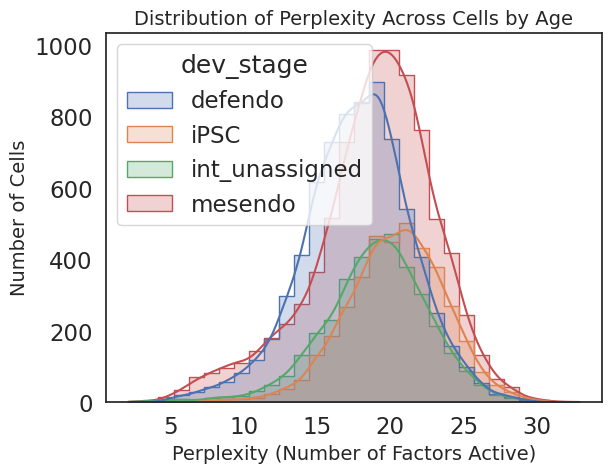

In [66]:
# Calculate entropy for each cell (each row sums to 1)
entropy = -np.sum(assign_post * np.log(assign_post + 1e-12), axis=1)  # Small epsilon added for numerical stability

# Calculate perplexity for each cell
perplexity = np.exp(entropy)

# Combine results for better readability
results = np.column_stack((entropy, perplexity))

# Display the first few results
print("Entropy and Perplexity for each cell (first 10 cells):")
print(results[:10])

splice_adata.obs["perplexity"] = perplexity
splice_adata.obs["entropy"] = entropy

# Assuming `perplexity` is already added to `splice_adata.obs` as a column
sns.histplot(data=splice_adata.obs, x="perplexity", hue="dev_stage", bins=30, kde=True, element="step")
plt.xlabel("Perplexity (Number of Factors Active)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Perplexity Across Cells by Age", fontsize=14)
plt.show()

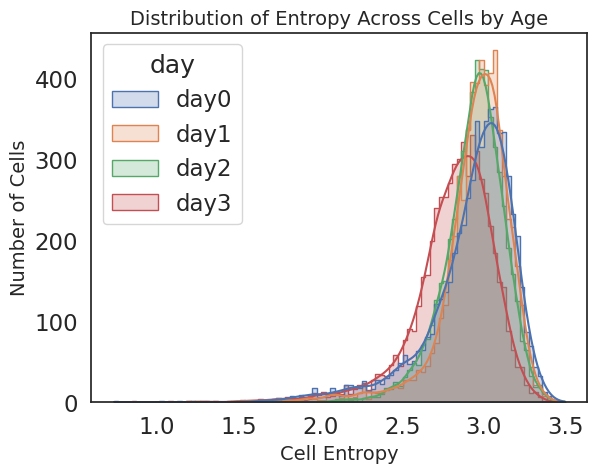

In [67]:
# Assuming `perplexity` is already added to `splice_adata.obs` as a column
sns.histplot(data=splice_adata.obs, x="entropy", hue="day", bins=100, kde=True, element="step")
plt.xlabel("Cell Entropy", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Entropy Across Cells by Age", fontsize=14)
plt.show()

In [116]:
splice_adata

AnnData object with n_obs × n_vars = 23790 × 30452
    obs: 'cell_id', 'library_name', 'donor', 'day', 'experiment', 'plate_id', 'plate_well_id', 'donor_short_id', 'donor_long_id', 'cell_id_index', 'factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5', 'factor_6', 'factor_7', 'factor_8', 'factor_9', 'factor_10', 'factor_11', 'factor_12', 'factor_13', 'factor_14', 'factor_15', 'factor_16', 'factor_17', 'factor_18', 'factor_19', 'factor_20', 'factor_21', 'factor_22', 'factor_23', 'factor_24', 'factor_25', 'factor_26', 'factor_27', 'factor_28', 'factor_29', 'factor_30', 'factor_31', 'factor_32', 'factor_33', 'factor_34', 'factor_35', 'factor_36', 'factor_37', 'factor_38', 'factor_39', 'factor_40', 'factor_41', 'factor_42', 'factor_43', 'factor_44', 'factor_45', 'factor_46', 'factor_47', 'factor_48', 'factor_49', 'factor_50', 'pseudo', 'dev_stage', 'perplexity', 'entropy'
    var: 'factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5', 'factor_6', 'factor_7', 'factor_8', 'factor_9

### Calcualte Entropy and Perplexity across Junctions!

In [82]:
# remove index names from splice_adata.var 
splice_adata.var = splice_adata.var.reset_index(drop=True)

In [83]:
# Calculate entropy for each junction (columns represent factors for each junction)
entropy = -np.sum(psi_learned.T * np.log(psi_learned.T + 1e-12), axis=1)

# Calculate perplexity for each junction
perplexity = np.exp(entropy)

# Combine results for better readability
results = np.column_stack((entropy, perplexity))

# Make into dataframe with columns junction_entropt and junction_perplexity
junc_results = pd.DataFrame(results, columns=["junction_entropy", "junction_perplexity"])
junc_results["junction_id"] = splice_adata.var["junction_id"]
junc_results.sort_values(by="junction_perplexity", ascending=False, inplace=True)
junc_results

,junction_entropy,junction_perplexity,junction_id
16954,18.328515,9.119539e+07,chr22_29291599_29292136_+
6673,18.308334,8.937341e+07,chr15_73703997_73704175_+
26348,18.278913,8.678229e+07,chr7_45103443_45104098_-
6015,18.259469,8.511118e+07,chr14_96562893_96564954_+
18787,18.247052,8.406093e+07,chr2_271939_272036_+
...,...,...,...
28822,0.329318,1.390020e+00,chr9_4834265_4841231_+
27641,0.308680,1.361626e+00,chr8_47966275_47977736_+
21461,0.302740,1.353563e+00,chr4_102809855_102826484_-
8807,0.290882,1.337607e+00,chr17_39202439_39202988_+


In [84]:
splice_adata.var = splice_adata.var.merge(junc_results, on="junction_id")

In [86]:
# drop these columns from splice_adat.var junction_entropy_x	junction_perplexity_x	junction_entropy_y	junction_perplexity_y
# splice_adata.var = splice_adata.var.drop(columns=["junction_entropy_x", "junction_perplexity_x", "junction_entropy_y", "junction_perplexity_y"])

In [87]:
# drop Junction_Index from albf_scores 
albf_scores = albf_scores.drop(columns=["Junction_Index"])

In [88]:
albf_scores

,Factor,ALBF,junction_id_index
0,Factor 1,0.046019,0
1,Factor 1,0.041679,1
2,Factor 1,0.473625,2
3,Factor 1,0.401381,3
4,Factor 1,0.065617,4
...,...,...,...
1522595,Factor 50,0.176676,30447
1522596,Factor 50,0.120361,30448
1522597,Factor 50,0.064043,30449
1522598,Factor 50,0.090247,30450


In [89]:
splice_adata.var.sort_values(by="junction_id_index", ascending=False, inplace=True)
splice_adata.var.sort_values(by="junction_perplexity", ascending=True, inplace=False)

,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,...,junction_id_index,junction_id,gene_id,num_cells_with_junc,total_read_counts,Cluster,CountJuncs,gene_name,junction_entropy,junction_perplexity
4006,0.000131,0.005236,0.000342,0.000075,0.000149,0.000822,0.000133,0.000155,0.000038,0.000369,...,4006,chr12_54283093_54283207_+,ENSG00000135486.19,119,554,23314,11,HNRNPA1,0.227363,1.255286e+00
8807,0.998237,0.974473,0.994711,0.998828,0.998490,0.997583,0.990424,0.992964,0.995755,0.997496,...,8807,chr17_39202439_39202988_+,ENSG00000108298.12,37556,8238789,30033,3,RPL19,0.290882,1.337607e+00
21461,0.997968,0.994098,0.993383,0.998103,0.999381,0.997189,0.998145,0.994031,0.998133,0.997817,...,21461,chr4_102809855_102826484_-,ENSG00000109332.20,34116,1014388,10043,3,UBE2D3,0.302740,1.353563e+00
27641,0.000023,0.000579,0.000022,0.000515,0.000082,0.000250,0.000539,0.000079,0.005145,0.000519,...,27641,chr8_47966275_47977736_+,ENSG00000104738.19,178,705,16379,10,MCM4,0.308680,1.361626e+00
28822,0.999316,0.998216,0.835066,0.999104,0.999705,0.997748,0.999214,0.999589,0.999490,0.998323,...,28822,chr9_4834265_4841231_+,ENSG00000120158.12,15947,99140,17698,3,RCL1,0.329318,1.390020e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18787,0.393261,0.258292,0.339165,0.460734,0.374476,0.360545,0.378635,0.320061,0.374871,0.384882,...,18787,chr2_271939_272036_+,ENSG00000143727.16,32568,493859,4795,5,ACP1,18.247052,8.406093e+07
6015,0.359431,0.341438,0.410296,0.431554,0.382999,0.391014,0.367114,0.361565,0.341194,0.346474,...,6015,chr14_96562893_96564954_+,ENSG00000090060.19,17930,91511,25569,4,PAPOLA,18.259469,8.511118e+07
26348,0.405344,0.283775,0.338634,0.372122,0.351547,0.422916,0.355014,0.372504,0.351842,0.395045,...,26348,chr7_45103443_45104098_-,ENSG00000136270.14,25647,224469,15787,4,TBRG4,18.278913,8.678229e+07
6673,0.338868,0.372358,0.391711,0.329973,0.383287,0.347125,0.341640,0.387302,0.335425,0.324926,...,6673,chr15_73703997_73704175_+,ENSG00000103855.18,21416,157308,26896,4,CD276,18.308334,8.937341e+07


### Calcualte Entropy and Perplexity across Factors to see how many cell types they are active in ?

### Look at factor-factor correlations in terms of cell usage - also do this usage junction PSI

In [90]:
splice_adata.obs[factor_columns].shape

(23790, 50)

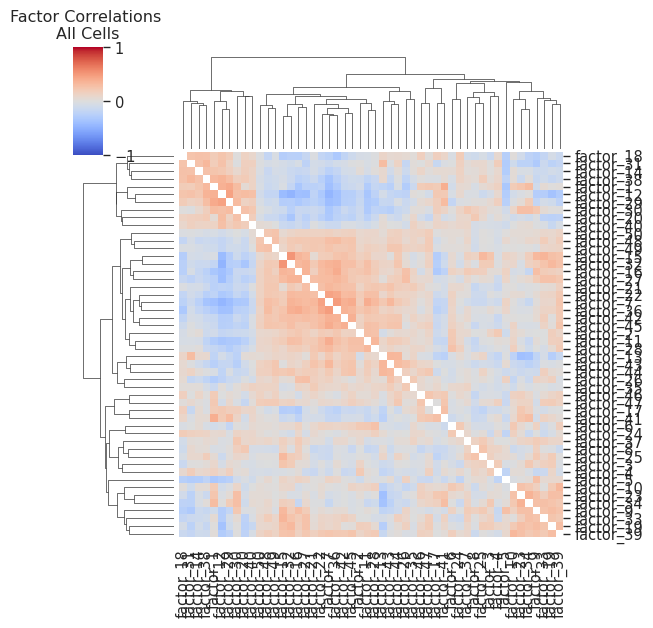

In [91]:
factor_corr_spearman_all = splice_adata.obs[factor_columns].corr(method='spearman')

# Create a mask to hide the diagonal
mask = np.eye(len(factor_corr_spearman_all), dtype=bool)

# Set overall font size smaller using Seaborn context
sns.set_context("paper", font_scale=1.2)  # Adjust `font_scale` for smaller/larger font

# Create a clustermap with masked diagonal
g = sns.clustermap(
    factor_corr_spearman_all, annot=False, cmap='coolwarm', center=0, mask=mask,
    yticklabels=1, xticklabels=1, figsize=(6, 6), vmin=-1, vmax=1)

plt.title("Factor Correlations \nAll Cells")
plt.show()

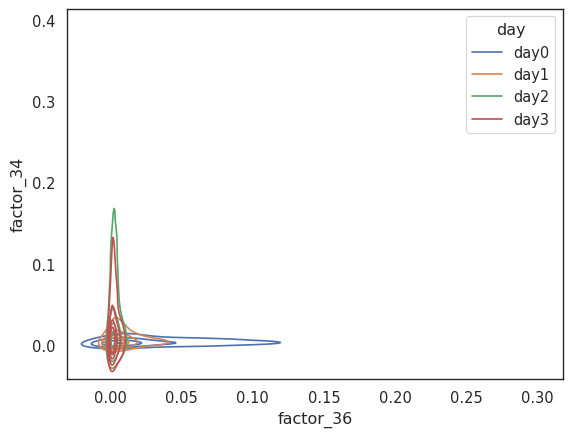

In [93]:
# let's look at correlation of cells activities among factor_1 and factor_13 

# Plot scatterplot with density visualization
sns.kdeplot(
    data=splice_adata.obs,
    x="factor_36",
    y="factor_34",
    levels=5, thresh=.2,
    hue="day")
plt.show()

### Look at factor-factor correlations using junction PSI values...

In [94]:
psi_learned_df = pd.DataFrame(psi_learned).T
psi_learned_df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.372128,0.529357,0.488256,0.043326,0.277457,0.247532,0.897251,0.015824,0.563058,0.207275,...,0.452681,0.663601,0.749518,0.836612,0.734451,0.301720,0.287127,0.326200,0.556180,0.612934
1,0.653779,0.457197,0.498655,0.966200,0.709050,0.735967,0.114895,0.987306,0.472973,0.697787,...,0.532968,0.318346,0.289658,0.194930,0.285620,0.855487,0.731780,0.767101,0.658671,0.371888
2,0.046943,0.488460,0.054680,0.031511,0.003972,0.087689,0.180523,0.024776,0.009274,0.037036,...,0.028399,0.281908,0.466163,0.186156,0.070668,0.057930,0.085612,0.027136,0.086916,0.156559
3,0.976258,0.504119,0.803827,0.981444,0.974661,0.923248,0.834653,0.963307,0.973932,0.941226,...,0.972530,0.818417,0.579505,0.724768,0.831610,0.916962,0.908547,0.962347,0.904819,0.752711
4,0.252643,0.368365,0.194379,0.207872,0.046151,0.091382,0.119275,0.490557,0.102110,0.188392,...,0.083324,0.067296,0.201629,0.527723,0.297569,0.239471,0.262768,0.033604,0.176113,0.150182


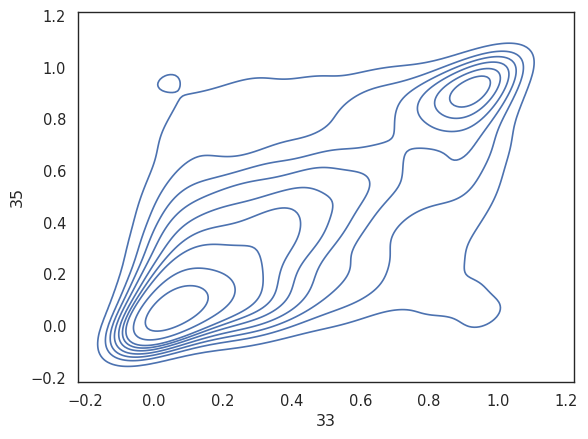

In [96]:
sns.kdeplot(
    data=psi_learned_df.sample(5000),x=33, y=35)
plt.show()

In [97]:
factor_corr_spearman_juncs = psi_learned_df.corr(method='spearman')

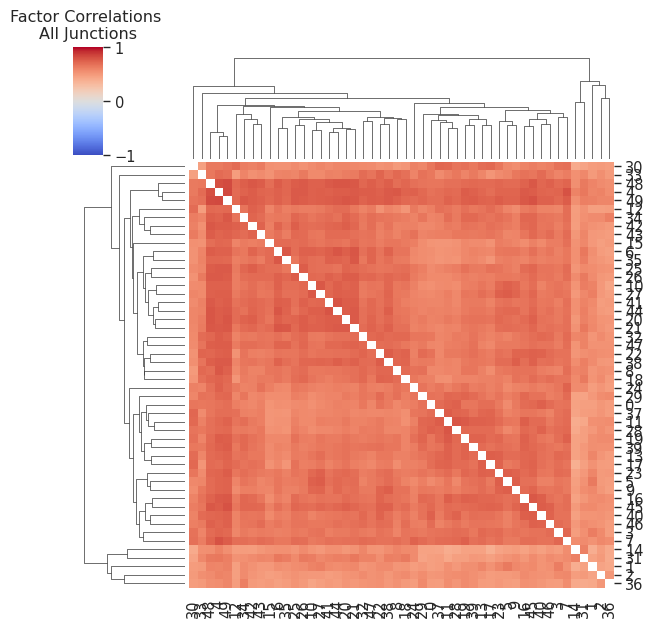

In [98]:
# Create a mask to hide the diagonal
mask = np.eye(len(factor_corr_spearman_juncs), dtype=bool)

# Set overall font size smaller using Seaborn context
sns.set_context("paper", font_scale=1.2)  # Adjust `font_scale` for smaller/larger font

# Create a clustermap with masked diagonal
g = sns.clustermap(
    factor_corr_spearman_juncs, annot=False, cmap='coolwarm', center=0, mask=mask,
    yticklabels=1, xticklabels=1, figsize=(6, 6), vmin=-1, vmax=1)

plt.title("Factor Correlations \nAll Junctions")
plt.show()

### Look at junction annotations!

In [99]:
# junction_id  Cluster  usage_ratio
splice_adata_var = juncs_factors_albf[["junction_id", "Cluster"]].drop_duplicates()
splice_adata_var["usage_ratio"] = 0

# Convert junction_ids
splice_junctions = ja.convert_junction_ids(splice_adata_var)

In [100]:
splice_junctions[0]

{'chrom': 'chr10',
 'start': 100185637,
 'end': 100185903,
 'name': 'junction_1',
 'strand': '-',
 'usage_ratio': 0}

In [101]:
# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

 14%|█▎        | 4119/30452 [03:47<24:15, 18.09it/s]  


KeyboardInterrupt: 

In [ ]:
print(junction_annotation_results[1])

In [ ]:
junction_annotation_results_df = pd.DataFrame(junction_annotation_results)

# if label_5_prime is "annotated on 5'" or label_3_prime is "annotated on 3'", then add annotation columns where values would be "one side" if both then "both sides" and if none then "none"
junction_annotation_results_df["annotation"] = "none"
junction_annotation_results_df.loc[(junction_annotation_results_df["label_5_prime"] == "annotated on 5'"), "annotation"] = "one side"
junction_annotation_results_df.loc[(junction_annotation_results_df["label_3_prime"] == "annotated on 3'"), "annotation"] = "one side"
# now check if both are annotated
junction_annotation_results_df.loc[(junction_annotation_results_df["label_5_prime"] == "annotated on 5'") & (junction_annotation_results_df["label_3_prime"] == "annotated on 3'"), "annotation"] = "both sides"
junction_annotation_results_df.annotation.value_counts()

In [ ]:
# save junction_annotation_results_df to file 
junction_annotation_results_df.to_csv("junction_annotation_results_df.csv")

In [ ]:
junction_annotation_results_df

In [ ]:
# add original junction_id to the junction_annotation_results_df
junction_annotation_results_df["junction_id"] = splice_adata_var["junction_id"].values

In [ ]:
# add annotation to splice_adata.var 
splice_adata.var = splice_adata.var.merge(junction_annotation_results_df, on="junction_id")

In [ ]:
plot_top_factor_distributions(splice_adata, top_factors=["factor_17", "factor_4", "factor_2"], age_column="age", plot_type="boxenplot")

In [ ]:
# now let's find top 10% of junctions with highest ALBF scores for factor 2
top_10_percent = int(0.1 * len(splice_adata.var))

# get percent of top junctions that are annotated (both sides) vs (vs one side) vs unannotated for each factor
junc_anno_factors = {}
factor_columns

for factor in factor_columns:
    top_junctions = splice_adata.var.sort_values(by=factor, ascending=False).head(top_10_percent)
    junc_anno_factors[factor] = top_junctions.annotation.value_counts()
    
# convert to dataframe
junc_anno_factors_df = pd.DataFrame(junc_anno_factors).T
junc_anno_factors_df

# get the percentage of annotated junctions for each factor 
junc_anno_factors_df["annotated_percent"] = junc_anno_factors_df["both sides"] / top_10_percent * 100
# get the percentage of unannotated junctions for each factor
junc_anno_factors_df["unannotated_percent"] = junc_anno_factors_df["none"] / top_10_percent * 100
# get the percentage of junctions annotated on one side for each factor
junc_anno_factors_df["one_side_percent"] = junc_anno_factors_df["one side"] / top_10_percent * 100

In [ ]:
plot_top_factor_distributions(splice_adata, top_factors=["factor_26"], age_column="age", plot_type="boxenplot")

In [ ]:
sns.kdeplot(
    data=splice_adata.obs.sample(10000),
    x="factor_2",
    y="factor_12",
    levels=5, thresh=.2,
    hue="age")
plt.show()

In [ ]:
sns.kdeplot(
    data=splice_adata.obs.sample(10000),
    x="factor_2",
    y="factor_26",
    levels=5, thresh=.2,
    hue="age")
plt.show()

In [ ]:
# keep just the columns that have "factor" in them and melt the table 
coef_splicing_df = coef_splicing.filter(like="factor").reset_index().melt(id_vars="index", var_name="factor", value_name="count")
# rename columns to age group, factor and coefficient 
coef_splicing_df.columns = ["age_group", "factor", "coefficient"]
# sort by absolute coefficient value
coef_splicing_df = coef_splicing_df.sort_values(by="coefficient", ascending=False)
coef_splicing_df

In [ ]:
# let's extract junction_id and perxplecity from splice_adata.var and merge with juncs_factors_albf
splice_adata_var = splice_adata.var[["junction_id", "junction_perplexity"]].drop_duplicates()
juncs_factors_albf = juncs_factors_albf.merge(splice_adata_var, on="junction_id")

In [ ]:
juncs_factors_albf.sort_values(by="ALBF", ascending=False)

In [ ]:
# let's find top 5 cell_types and label them and all other cells make grey 
top_5_cell_types = splice_adata.obs["cell_type_grouped"].value_counts().head(20).index.values

# create a new column in splice_adata.obs called "cell_type_grouped_top5" and label the top 5 cell types and all other cell types as "other"
splice_adata.obs["cell_type_grouped_top5"] = splice_adata.obs["cell_type_grouped"].apply(lambda x: x if x in top_5_cell_types else "other")

# make umap plot with cell_type_grouped_top5 as color
sc.pl.umap(splice_adata, color=["cell_type_grouped_top5"])

In [ ]:
sc.pl.umap(splice_adata, color=["age", "factor_2", "factor_26"])

In [ ]:
junction_id_index = 35300  
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

In [ ]:
junction_id_index = 26682  
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

In [ ]:
# make barplot ordered by annotated_percent in decreasing order 
junc_anno_factors_df.sort_values(by="annotated_percent", ascending=False, inplace=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=junc_anno_factors_df, x=junc_anno_factors_df.index, y="annotated_percent")
plt.xticks(rotation=45)
plt.xlabel("Factor")
plt.ylabel("Percentage of Annotated Junctions")
plt.title("Percentage of Annotated Junctions for Top 10% Junctions by Factor")
plt.show()

### Fgfr2 specific visualization of mutually exclusive exons

In [ ]:
splice_adata_var = splice_adata_var[splice_adata_var["Cluster"] == 26488] # Fgfr2 related cluster
# Let's limit to just Fgfr2 mutually exclusive exons isoforms 120187 and 122054
unique_transcripts = ["ENSMUST00000120187.8", "ENSMUST00000122054.7"] # Fgfr2 mutually exclusive exons

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(unique_transcripts, db)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
junc_annots = ja.check_junction_annotation(splice_junctions, db)

In [ ]:
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start, region_end, base_width=10, trans_height=0.3, show_usage=False, show_junc_lines=True)

In [ ]:
junction_id_index = 42968  #chr7_130196374_130198418_- --> 	 
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

In [ ]:
junction_id_index = 42969 # chr7_130196374_130199757_- # Replace with the actual index for the junction of interest
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)